<a href="https://colab.research.google.com/github/emmanguyen01-spec/Coding-Exercise---ML-Basics/blob/main/ML/forecasting_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'redfin-housing-market-data' dataset.
Path to dataset files: /kaggle/input/redfin-housing-market-data
['zip_code_market_tracker.tsv000', 'state_market_tracker.tsv000', 'neighborhood_market_tracker.tsv000', 'us_national_market_tracker.tsv000', 'county_market_tracker.tsv000']
  period_begin  period_end  period_duration region_type  region_type_id  \
0   2013-09-01  2013-09-30               30    national              11   
1   2012-04-01  2012-04-30               30    national              11   
2   2018-09-01  2018-09-30               30    national              11   
3   2019-07-01  2019-07-31               30    national              11   
4   2013-01-01  2013-01-31               30    national              11   

   table_id is_seasonally_adjusted     region      city state  ...  \
0      1400                      t   National  National  U.S.  ...   
1      1400                      f   National  National  U.S.  ...   
2      1400          

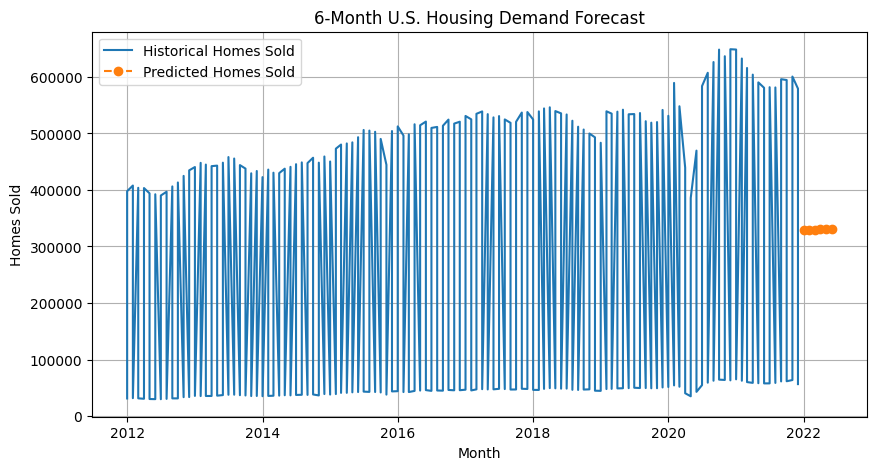

In [3]:
import pandas as pd
import numpy as np
import os
import kagglehub

from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Data Source:
# Kaggle - Redfin Housing Market Data 2012-2021
# https://www.kaggle.com/datasets/thuynyle/redfin-housing-market-data

# Download latest version
path = kagglehub.dataset_download(
    "thuynyle/redfin-housing-market-data"
)

print("Path to dataset files:", path)

# See which files are inside the dataset
print(os.listdir(path))

# Load the U.S. national housing market data
df = pd.read_csv(
    os.path.join(path, "us_national_market_tracker.tsv000"),
    sep='\t'
)

# Preview dataset
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

# Keep seasonally adjusted national data only
df = df[df['is_seasonally_adjusted'] == 't'].copy()

# Keep only the columns needed
df = df[['period_begin', 'homes_sold']]

# Convert date column to datetime
df['period_begin'] = pd.to_datetime(df['period_begin'])

# Remove missing values
df = df.dropna()

# Sort by date
df = df.sort_values('period_begin').reset_index(drop=True)

# Create a simple month number for regression
df['month'] = range(1, len(df) + 1)

# Preview cleaned data
print(df.head())
print("\nNumber of monthly records:", len(df))

# Features and target
X = df[['month']]
y = df['homes_sold']

# Train the model
model = LinearRegression()
model.fit(X, y)

# Predict demand for the next 6 months
last_month = df['month'].max()

future_months = pd.DataFrame({
    'month': range(last_month + 1, last_month + 7)
})

predictions = model.predict(future_months)

# Create future calendar dates
last_date = df['period_begin'].max()

future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=6,
    freq='MS'
)

forecast = pd.DataFrame({
    'period_begin': future_dates,
    'predicted_homes_sold': predictions
})

print("\n6-Month Housing Demand Forecast:")
print(forecast)

# Plot historical and predicted demand
plt.figure(figsize=(10, 5))

plt.plot(
    df['period_begin'],
    df['homes_sold'],
    label='Historical Homes Sold'
)

plt.plot(
    forecast['period_begin'],
    forecast['predicted_homes_sold'],
    linestyle='--',
    marker='o',
    label='Predicted Homes Sold'
)

plt.xlabel('Month')
plt.ylabel('Homes Sold')
plt.title('6-Month U.S. Housing Demand Forecast')
plt.legend()
plt.grid(True)
plt.show()